In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor 
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler 

In [2]:
data=pd.read_csv("CarPrice_Assignment (1) (1).csv")
print(data.head())
print(data.info()) 

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [3]:
data=data.drop(['CarName', 'car_ID'], axis=1)
data=pd.get_dummies(data, drop_first=True) 

In [4]:
X=data.drop('price',axis=1)
y=data['price']

In [5]:
scaler=StandardScaler()
X=scaler.fit_transform(X)
y=scaler.fit_transform(np.array(y).reshape(-1,1))

In [6]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
sgd_model=SGDRegressor(max_iter=1000,tol=1e-3)



In [8]:
sgd_model.fit(X_train, y_train)


C:\ProgramData\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor()

In [9]:
y_pred=sgd_model.predict(X_test)

In [10]:
mse=mean_squared_error(y_test,y_pred)

In [14]:
print('Name:Ashna.M ')
print('Reg.no: 212225040032 ')
print(f"MSE: {mean_squared_error(y_test,y_pred):.2f}")
print(f"R^2: {r2_score(y_test,y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test,y_pred):.2f}")

Name:Ashna.M 
Reg.no: 212225040032 
MSE: 0.22
R^2: 0.8233
MAE: 0.32



Model Coefficients:
Coefficients: [ 0.03512371  0.11294738  0.01736757  0.17567738  0.0179046   0.16215312
  0.27367069 -0.01655346 -0.07933687  0.0055435   0.10609074  0.0353266
 -0.04088341 -0.05190969 -0.02006454  0.02154807  0.01747302 -0.0100782
 -0.08100722 -0.00804214 -0.08880458 -0.03777883  0.06663829  0.21281159
  0.01663205 -0.10201018  0.06781179 -0.01600724  0.00981951  0.00918615
 -0.03046581 -0.14516594 -0.07330808  0.00073392 -0.02526647  0.00918615
 -0.0043879  -0.01744707  0.02006454 -0.01782617 -0.02999259 -0.04095589
 -0.01653855]
Intercept: [-0.01048349]


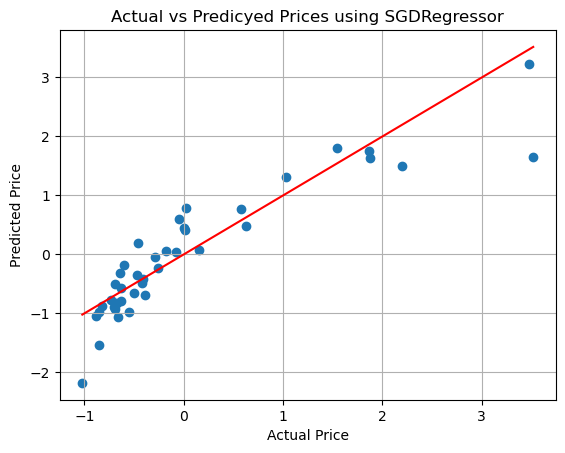

In [15]:
print("\nModel Coefficients:")
print("Coefficients:",sgd_model.coef_)
print("Intercept:",sgd_model.intercept_)
plt.scatter(y_test,y_pred)
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red')
plt.title("Actual vs Predicyed Prices using SGDRegressor")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True)
plt.show()